# Week 6 Day 1: AFL Data Foundations — EDA, Feature Engineering & Prediction Targets

**Goal:** 
before building any models or the chat agent, gotta a full understanding of the AFL data, lock in exact definitions for "team win" and "top player", explore the data, and build the feature table that the rest of the week will use.

Three files are used here:
- `afl_players_round_by_round_stats_raw.csv` : one row per player per match (round-by-round stats)
- `team_matches_home_away_raw.csv` : one row per team per match (home/away perspective)
- `merged_players.csv` : season-level player stats + player bio info, already merged in Week 2 so reusing it 


## Task 1: Data Inventory & Understanding

### Loading and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")
pd.set_option('display.max_columns', None)

players = pd.read_csv('afl_players_round_by_round_stats_raw.csv')
team_matches = pd.read_csv('team_matches_home_away_raw.csv')
merged = pd.read_csv('merged_players.csv')

#shape 
print("players (round-by-round):", players.shape)
print("team_matches (home/away):", team_matches.shape)
print("merged (season level):", merged.shape)

players (round-by-round): (274089, 36)
team_matches (home/away): (15808, 19)
merged (season level): (25081, 69)


In [2]:
players.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,3.0,1.0,NaN,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,5.0,14.0,NaN,NaN,NaN,NaN,4.0,3.0,5.0,1.0,NaN,NaN,NaN,10.0,7.0,1.0,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,8.0,15.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,4.0,3.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [3]:
team_matches.head()

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


In [4]:
merged.head()

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assists,total_score,total_fantasy_points,total_percentage_played,avg_kicks,avg_marks,avg_handballs,avg_disposals,avg_goals,avg_behinds,avg_hit_outs,avg_tackles,avg_rebound_50s,avg_inside_50s,avg_clearances,avg_clangers,avg_free_kicks_for,avg_free_kicks_against,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,2.0,82.0,18.0,2.0,2.0,8.0,10.0,2.0,6.0,0.0,20.0,20.0,1.0,5.0,13.0,0.0,1.0,20,278,253.0,5.7,3.0,7.0,12.7,1.0,0.7,27.3,6.0,0.7,0.7,2.7,3.3,0.7,2.0,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100.0,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,1.0,27.0,5.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1,61,81.0,3.0,2.0,2.0,5.0,0.0,1.0,27.0,5.0,0.0,0.0,0.0,3.0,0.0,2.0,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100.0,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,0.0,24.0,4.0,1.0,2.0,3.0,4.0,1.0,3.0,0.0,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6,74,83.0,5.0,3.0,6.0,11.0,1.0,0.0,24.0,4.0,1.0,2.0,3.0,4.0,1.0,3.0,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100.0,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6,22,54.0,2.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100.0,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,3.0,0.0,25.0,1.0,17.0,13.0,11.0,7.0,1.0,0.0,68.0,36.0,3.0,3.0,12.0,2.0,0.0,63,443,0.0,3.1,1.1,5.2,8.3,0.8,0.2,0.0,2.1,0.1,1.4,1.1,0.9,0.6,0.1,5.7,3.0,0.2,0.2,1.0,0.2,0.0,5.3,36.9,0.0,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87.0,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"



### What each table represents

**`players` (afl_players_round_by_round_stats_raw.csv)**
- Grain: **one row per player, per match.** Every time a player played a round, that's a row.
- Key columns: `player_id`, `team`, `opponent`, `year`, `round`, `match_date`, `result` (W/L/D for that player's team), and the box score stats (kicks, disposals, goals, tackles, etc.)
- There's no single `match_id` column, but a match can be identified by `team` + `opponent` + `match_date` (or `year`+`round`+`team`+`opponent`).

**`team_matches` (team_matches_home_away_raw.csv)**
- Grain: **one row per team, per match** — so every match shows up twice (once from the home team's side, once from the away team's side).
- Key columns: `team_name`, `opponent`, `match_date`, `round`, `year`, `home_away` (H/A), `team_score`, `opponent_score`, `result`, `margin`, `venue`.
- Joining the two rows for the same match (matching on `match_date` + the two team names) gives you a proper match-level table.

**`merged` (merged_players.csv)**
- Grain: **one row per player, per season, per team, split by home-and-away vs finals** (`is_finals` True/False). This is the Week 2 output: player round-by-round stats combined  up to season totals/averages, joined with player bio info (name, DOB, height, weight, debut date, etc.)

### How the tables join
- `players` with `team_matches`: on `team` + `opponent` + `match_date` (gets you venue, team score context, home/away for that player's match)
- `players` with `merged`: on `player_id` + `year` + `team`
- `team_matches`: matches to itself (self-join on `match_date` + swapped team/opponent) to build one row per match instead of two

There's no explicit `match_id` in the raw files so we will build one below

In [5]:
for name, df in [('players', players), ('team_matches', team_matches), ('merged', merged)]:
    print(f"==== {name} =====")
    print("years covered:", df['year'].min(), "-", df['year'].max())
    print("number of seasons:", df['year'].nunique())
    print()

==== players =====
years covered: 1983 - 2025
number of seasons: 43

==== team_matches =====
years covered: 1983 - 2025
number of seasons: 43

==== merged =====
years covered: 1983 - 2025
number of seasons: 43



Okay so its confirmed that all 3 of the datasets cover data from 1983 till 2025. And all of them have the exact number of seasons which is 43. Now thats really good for us. This means the overall data across the files is consistent.
### Checking teams and players

In [6]:
print("Teams in players table:", players['team'].nunique())
print("Teams in team_matches table (raw, uncleaned):", team_matches['team_name'].nunique())
print("Players in players table:", players['player_id'].nunique())
print("Players in merged table:", merged['player_id'].nunique())
print("Rows in team_matches:", len(team_matches), "-> matches (rows/2):", len(team_matches)//2)

Teams in players table: 20
Teams in team_matches table (raw, uncleaned): 40
Players in players table: 3109
Players in merged table: 2843
Rows in team_matches: 15808 -> matches (rows/2): 7904


In [7]:
# checking seasons
matches_per_year = (
    team_matches.groupby("year")["id"]
    .nunique()
    .reset_index(name="num_matches")
)

display(matches_per_year)

,year,num_matches
0,1983,276
1,1984,276
2,1985,276
3,1986,276
4,1987,320
5,1988,320
6,1989,320
7,1990,322
8,1991,344
9,1992,344


In [8]:
# team names
sorted(team_matches["team_name"].unique())

['\t Adelaide Crows ',
 '\tBrisbane Bears',
 '\tBrisbane Lions',
 '\tCarlton Blues',
 '\tCollingwood Magpies',
 '\tEssendon Bombers',
 '\tFitzroy Lions',
 '\tFremantle Dockers',
 '\tGeelong Cats',
 '\tGold Coast Suns',
 '\tGreater Western Sydney Giants',
 '\tHawthorn Hawks',
 '\tMelbourne Demons',
 '\tNorth Melbourne Kangaroos',
 '\tPort Adelaide Power',
 '\tRichmond Tigers',
 '\tSt Kilda Saints',
 '\tSydney Swans',
 '\tW. Bulldogs',
 '\tWest Coast Eagles',
 ' Adelaide Crows ',
 'Brisbane Bears',
 'Brisbane Lions',
 'Carlton Blues',
 'Collingwood Magpies',
 'Essendon Bombers',
 'Fitzroy Lions',
 'Fremantle Dockers',
 'Geelong Cats',
 'Gold Coast Suns',
 'Greater Western Sydney Giants',
 'Hawthorn Hawks',
 'Melbourne Demons',
 'North Melbourne Kangaroos',
 'Port Adelaide Power',
 'Richmond Tigers',
 'St Kilda Saints',
 'Sydney Swans',
 'W. Bulldogs',
 'West Coast Eagles']

In [9]:
team_history = (
    team_matches.groupby("team_name")["year"]
    .agg(first_year="min",
         last_year="max")
    .sort_values("first_year")
)

display(team_history)

,first_year,last_year
team_name,,
\tCarlton Blues,1983,2025
\tEssendon Bombers,1983,2025
\tFitzroy Lions,1983,1995
\tGeelong Cats,1983,2025
\tMelbourne Demons,1983,2025
\tRichmond Tigers,1983,2025
\tHawthorn Hawks,1983,2025
\tSt Kilda Saints,1983,2025
Collingwood Magpies,1983,2025


**team_matches shows 40 unique team names but there are only 20 real teams.** That's a data quality problem, similar to what we faced in week 2. Some rows have leading whitespace or a tab character in the name, and the Western Bulldogs are recorded as `W. Bulldogs` instead of the full name used everywhere else. This gets fixed in the data quality section below, similar to week 2 :D

### Structural changes over time (things that affect how the data should be read)
- **2020 season is short:** As we can see above, COVID cut the season down, so 2020 has noticeably fewer matches than other years. Any "per season" comparison needs to keep this in mind, or 2020 will look like an outlier team
- **Club mergers/renames in the data:** `Fitzroy Lions` stops appearing after 1996 and `Brisbane Bears` stops appearing after 1996, they merged into the `Brisbane Lions` club from 1997 onward, which is why both older names disappear and a new one appears. The data isn't missing, thats just what hapened in the history of clubs.
- **Expansion teams:** `Gold Coast Suns` (2011) and `Greater Western Sydney Giants` (2012) enter the competition partway through the dataset, so their season counts start later than the others.

These are worth knowing before building form eatures, since a team having zero prior history isn't always a data problem, sometimes the team just didn't exist yet.

In [10]:
print("Fitzroy Lions last year seen:", players.loc[players['team']=='Fitzroy Lions','year'].max())
print("Brisbane Bears last year seen:", players.loc[players['team']=='Brisbane Bears','year'].max())
print("Brisbane Lions first year seen:", players.loc[players['team']=='Brisbane Lions','year'].min())
print("Gold Coast Suns first year seen:", players.loc[players['team']=='Gold Coast Suns','year'].min())
print("GWS Giants first year seen:", players.loc[players['team']=='Greater Western Sydney Giants','year'].min())

Fitzroy Lions last year seen: 1996
Brisbane Bears last year seen: 1996
Brisbane Lions first year seen: 1997
Gold Coast Suns first year seen: 2011
GWS Giants first year seen: 2012


### Data quality checks

Checking for missing vals, duplicate rows, inconsistent naming, and outliers 

In [11]:
null_counts = players.isnull().sum()
null_pct = (null_counts / len(players) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': null_counts, 'missing_pct': null_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
score,274089,100.0
brownlow_votes,110481,40.3
goal_assist,103600,37.8
bounces,97343,35.5
hit_outs,96629,35.3
marks_inside_50,91378,33.3
contested_marks,90677,33.1
behinds,81093,29.6
goals,74737,27.3
percentage_of_game_played,69682,25.4


**Why so much missing in `players`:** the AFL didn't track every stat in every era. Things like `hit_outs`, `contested_marks`, `goal_assist`, and `bounces` only started being officially recorded partway through history. So missing values here mostly mean "not tracked yet in that season", not "data entry error". `score` is 100% null in this table too, it's a leftover column, actual score lives in `team_matches` i think

Also worth noting: `kicks`, `handballs`, and `disposals` have some missing values even in modern years, these will need a simple fill (median or 0, depending on the column) before they're used in any model, but that's a Day 2 problem dont gotta touch it right now

In [12]:
#dupes
dup_rows = players.duplicated().sum()
dup_ids = players['id'].duplicated().sum()
print("Fully duplicated rows in players:", dup_rows)
print("Duplicated 'id' values in players:", dup_ids)
print()
print("Duplicated rows in team_matches:", team_matches.duplicated().sum())
print("Duplicated (player_id, year, team, is_finals) in merged:", 
      merged.duplicated(subset=['player_id','year','team','is_finals']).sum())

Fully duplicated rows in players: 10
Duplicated 'id' values in players: 10

Duplicated rows in team_matches: 0
Duplicated (player_id, year, team, is_finals) in merged: 0


In [13]:
# inconsistent team naming in team_matches
print("Raw unique team names in team_matches:", team_matches['team_name'].nunique())
print(sorted(team_matches['team_name'].unique())[:5], "...")

# outlier check: disposals should never be negative (it's kicks + handballs)
bad_disposals = players[players['disposals'] < 0]
print()
print("Rows where disposals is negative (impossible, should be kicks+handballs):", len(bad_disposals))
bad_disposals[['team','year','round','player_id','kicks','handballs','disposals']].head()

Raw unique team names in team_matches: 40
['\t Adelaide Crows ', '\tBrisbane Bears', '\tBrisbane Lions', '\tCarlton Blues', '\tCollingwood Magpies'] ...

Rows where disposals is negative (impossible, should be kicks+handballs): 723


,team,year,round,player_id,kicks,handballs,disposals
7,Brisbane Lions,2002,10,45747,1.0,1.0,-3.0
18,Sydney Swans,1997,8,45773,1.0,1.0,-3.0
19,Richmond Tigers,1993,11,45981,2.0,2.0,-1.0
26,Hawthorn Hawks,2000,16,45799,2.0,2.0,-1.0
56,Melbourne Demons,1998,10,45721,2.0,1.0,-2.0


In [14]:
players.describe()

,id,year,career_game_count,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,fantasy_points,score,margin
count,274089.000000,274089.000000,274089.000000,274089.000000,272789.000000,266038.000000,269656.000000,265636.000000,199352.000000,192996.000000,177460.000000,245407.000000,211233.000000,227515.000000,210170.00000,224124.000000,220247.000000,220814.000000,163608.000000,235263.000000,236091.000000,183412.000000,182711.000000,213943.000000,176746.000000,170489.000000,204407.000000,274089.000000,274089.000000,0.0,274089.000000
mean,317627.891590,2010.140524,90.230786,20.045664,9.202508,4.078474,6.368996,15.070299,0.825108,0.606044,2.375786,2.648698,1.828857,2.472729,1.88516,2.244017,1.049090,1.048946,0.222245,5.937823,9.551296,0.642019,0.713657,2.212019,0.610707,0.453478,81.060815,44786.577312,65.244187,NaN,0.164669
std,238902.057585,9.443820,72.632905,12.657641,4.709571,2.550794,4.077075,7.304748,1.147711,0.854019,6.804793,2.050778,1.881457,1.944291,2.15715,1.605687,1.010198,1.000923,0.685221,3.506373,5.248408,0.934531,1.152437,2.163776,1.218281,0.707634,14.821722,818.523942,28.110251,NaN,43.620652
min,1.000000,1983.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,43260.000000,-10.000000,NaN,-186.000000
25%,72923.000000,2002.000000,31.000000,9.000000,6.000000,2.000000,3.000000,10.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,3.000000,6.000000,0.000000,0.000000,1.000000,0.000000,0.000000,77.000000,44077.000000,45.000000,NaN,-29.000000
50%,397686.000000,2011.000000,73.000000,19.000000,9.000000,4.000000,6.000000,14.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,1.00000,2.000000,1.000000,1.000000,0.000000,5.000000,9.000000,0.000000,0.000000,2.000000,0.000000,0.000000,84.000000,44856.000000,64.000000,NaN,0.000000
75%,551104.000000,2018.000000,135.000000,30.000000,12.000000,6.000000,9.000000,20.000000,1.000000,1.000000,1.000000,4.000000,3.000000,4.000000,3.00000,3.000000,2.000000,2.000000,0.000000,8.000000,13.000000,1.000000,1.000000,3.000000,1.000000,1.000000,90.000000,45542.000000,84.000000,NaN,29.000000
max,619682.000000,2025.000000,432.000000,67.000000,37.000000,24.000000,35.000000,54.000000,16.000000,11.000000,80.000000,20.000000,18.000000,16.000000,22.00000,15.000000,10.000000,11.000000,3.000000,32.000000,41.000000,10.000000,14.000000,25.000000,20.000000,10.000000,100.000000,46374.000000,210.000000,NaN,186.000000


**Team naming is inconsistent in `team_matches`** whitespace/tab characters around names, and `W. Bulldogs` instead of `Western Bulldogs`. This gets cleaned below so it lines up with the 20 team names used in `players` and `merged`.

**723 rows have negative disposals**, which shouldn't be possible since `disposals = kicks + handballs`. This is a data entry error from the source  Small enough that the fix is just to flag and leave alone for now rather than guess-correct it, it's not worth inventing a value.

In [15]:
## cleaning team names
def clean_team_name(name):
    """Strip whitespace/tabs and fix the one known abbreviation mismatch."""
    name = str(name).strip().replace('\t', '').strip()
    if name == 'W. Bulldogs':
        name = 'Western Bulldogs'
    return name

team_matches['team_name'] = team_matches['team_name'].apply(clean_team_name)
team_matches['opponent'] = team_matches['opponent'].apply(clean_team_name)
team_matches['venue'] = team_matches['venue'].str.strip()

print("Teams in team_matches after cleaning:", team_matches['team_name'].nunique())
print("Matches team names in players table now?", 
      set(team_matches['team_name'].unique()) == set(players['team'].unique()))


#cleaning players and merged too
players["team"] = players["team"].apply(clean_team_name)
players["opponent"] = players["opponent"].apply(clean_team_name)

#merged

merged["team"] = merged["team"].apply(clean_team_name)

Teams in team_matches after cleaning: 20
Matches team names in players table now? True


In [16]:
print("Raw unique team names in team_matches:", team_matches['team_name'].nunique())
print(sorted(team_matches['team_name'].unique())[:5], "...")

Raw unique team names in team_matches: 20
['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies'] ...


In [17]:
players

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,3.0,1.0,NaN,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,5.0,14.0,NaN,NaN,NaN,NaN,4.0,3.0,5.0,1.0,NaN,NaN,NaN,10.0,7.0,1.0,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,8.0,15.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,4.0,3.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274084,18472,Adelaide Crows,2016,120,Sydney Swans,SF,L,33,7.0,4.0,9.0,NaN,0.0,0.0,0.0,0.0,4.0,2.0,3.0,0.0,0.0,0.0,0.0,7.0,7.0,1.0,0.0,3.0,0.0,0.0,80.0,44961,2016-09-17,51,NaN,-36
274085,25680,Greater Western Sydney Giants,2021,26,Geelong Cats,SF,L,39,6.0,4.0,5.0,NaN,0.0,0.0,0.0,0.0,4.0,2.0,0.0,2.0,1.0,1.0,0.0,2.0,9.0,0.0,0.0,4.0,0.0,0.0,79.0,44123,2021-09-03,38,NaN,-35
274086,618575,Melbourne Demons,2019,2,Gold Coast Suns,8,W,45,3.0,1.0,6.0,NaN,NaN,NaN,4.0,6.0,NaN,4.0,NaN,6.0,NaN,2.0,NaN,2.0,7.0,NaN,1.0,5.0,NaN,NaN,77.0,46165,2019-05-11,46,NaN,1
274087,617689,St Kilda Saints,2025,1,Adelaide Crows,1,L,31,4.0,1.0,8.0,NaN,NaN,NaN,27.0,2.0,NaN,1.0,4.0,NaN,2.0,NaN,NaN,8.0,4.0,NaN,NaN,2.0,NaN,NaN,78.0,46021,2025-03-16,68,NaN,-63


Nice its all clean

## Task 2: Define Prediction Targets Precisely


In [18]:
team_matches["result"].unique()

<StringArray>
['L', 'W', 'D']
Length: 3, dtype: str

In [19]:
# margin
team_matches["margin"].describe()

count    15808.000000
mean         0.001835
std         44.771226
min       -186.000000
25%        -30.000000
50%          0.000000
75%         30.000000
max        186.000000
Name: margin, dtype: float64

In [20]:
## brownlow votes
players["brownlow_votes"].value_counts().sort_index()

brownlow_votes
0.0    145441
1.0      6048
2.0      6044
3.0      6075
Name: count, dtype: int64


### Target 1: Match Winner

**Framing: classification, not regression.**

The target is defined at the **match level** as a 3-class label from the home team's perspective:
- `home_win` : home team's `result` == 'W'
- `away_win` : home team's `result` == 'L'
- `draw` : `result` == 'D'

**Why classification over regression on margin:** the actual business question for the assistant/prediction system is "who wins", not "by how many points". A regression model on margin would need to solve a harder problem (get the exact number close) to answer an easier question (get the sign right). Margin regression is worth keeping as a secondary/stretch target since the `margin` column is already there, but classification is the primary target.

### Target 2: "Top Player" (its got 2 defs)

**2a. Top disposal-getter**
- **Definition:** the player with the highest **disposals** in a given match (round-level) or the highest **average disposals per game** over a season (season-level).
- **Formula:** `disposals = kicks + handballs` (already provided as a column, this is just naming what it means).
- **Level of aggregation:** round-level (single match) or season-level (average across a season, using `merged_players`' `avg_disposals`).

**2b. Top goal-kicker**
- **Definition:** the player with the most **goals** in a given match, or the highest total/average goals across a season.
- **Formula:** uses the `goals` column directly (round-level) or `avg_goals` / total goals (season-level, from `merged`).

**2c. Composite score (fantasy-points based)**
- The dataset already includes a per-match `fantasy_points` column (standard AFL Fantasy scoring, built from disposals, marks, tackles, goals etc. combined into one number). Rather than re-deriving a new formula, this is used directly as the composite "who had the best game" metric, since re-deriving it risks double-counting stats that are already baked in.
- Season-level version: `avg_fantasy_points` from `merged_players` (already computed in Week 2).

**Note on Brownlow votes:** Brownlow votes are the points awarded by field umpires to the best players in each regular-season match of the AFL. The data also has a `brownlow_votes` column (3-2-1 votes awarded by umpires per match). This is kept as a separateversion of top player rather than merged into the composite, since it's not something a model would be predicting off the same underlying stats.

### Data dictionary

In [21]:
data_dictionary = pd.DataFrame([
    {"target_name": "match_winner", "definition": "3-class label: home_win / away_win / draw",
     "formula": "home team's result column mapped: W->home_win, L->away_win, D->draw",
     "level": "match"},
    {"target_name": "match_margin", "definition": "point margin of the match (secondary/stretch target)",
     "formula": "team_score - opponent_score (home team perspective)", "level": "match"},
    {"target_name": "top_disposal_getter", "definition": "player with most disposals",
     "formula": "max(disposals) per match, or avg_disposals per season", "level": "match or season"},
    {"target_name": "top_goal_kicker", "definition": "player with most goals",
     "formula": "max(goals) per match, or avg_goals/total goals per season", "level": "match or season"},
    {"target_name": "top_player_composite", "definition": "best overall game, fantasy-points based",
     "formula": "fantasy_points column (match level) / avg_fantasy_points (season level, from merged_players)",
     "level": "match or season"},
])
data_dictionary

,target_name,definition,formula,level
0,match_winner,3-class label: home_win / away_win / draw,"home team's result column mapped: W->home_win,...",match
1,match_margin,point margin of the match (secondary/stretch t...,team_score - opponent_score (home team perspec...,match
2,top_disposal_getter,player with most disposals,"max(disposals) per match, or avg_disposals per...",match or season
3,top_goal_kicker,player with most goals,"max(goals) per match, or avg_goals/total goals...",match or season
4,top_player_composite,"best overall game, fantasy-points based",fantasy_points column (match level) / avg_fant...,match or season


## Task 3: Exploratory Data Analysis

### Building a proper match-level table first

`team_matches` has two rows per match (one per team). To do match-level analysis (win rates, home ground advantage), the home team's row is used as the canonical one row per match.

In [22]:
matches = team_matches[team_matches['home_away'] == 'H'].copy()
matches = matches.rename(columns={
    'team_name': 'home_team', 'opponent': 'away_team',
    'team_score': 'home_score', 'opponent_score': 'away_score',
    'result': 'home_result'
})
matches['match_date'] = pd.to_datetime(matches['match_date'])
matches['home_win'] = (matches['home_result'] == 'W').astype(int)
matches['is_draw'] = (matches['home_result'] == 'D').astype(int)

print("Match-level table shape:", matches.shape)
matches[['home_team','away_team','match_date','year','round','home_score','away_score','home_result']].head()

Match-level table shape: (7904, 21)


,home_team,away_team,match_date,year,round,home_score,away_score,home_result
1,North Melbourne Kangaroos,Hawthorn Hawks,1994-09-10,1994,QF,114,91,W
5,Sydney Swans,West Coast Eagles,2019-06-09,2019,12,116,71,W
8,Western Bulldogs,St Kilda Saints,2000-05-05,2000,9,105,104,W
11,Western Bulldogs,Melbourne Demons,2000-05-28,2000,12,108,83,W
13,Western Bulldogs,North Melbourne Kangaroos,2000-06-18,2000,15,106,102,W


#### 1. Home ground advantage over time

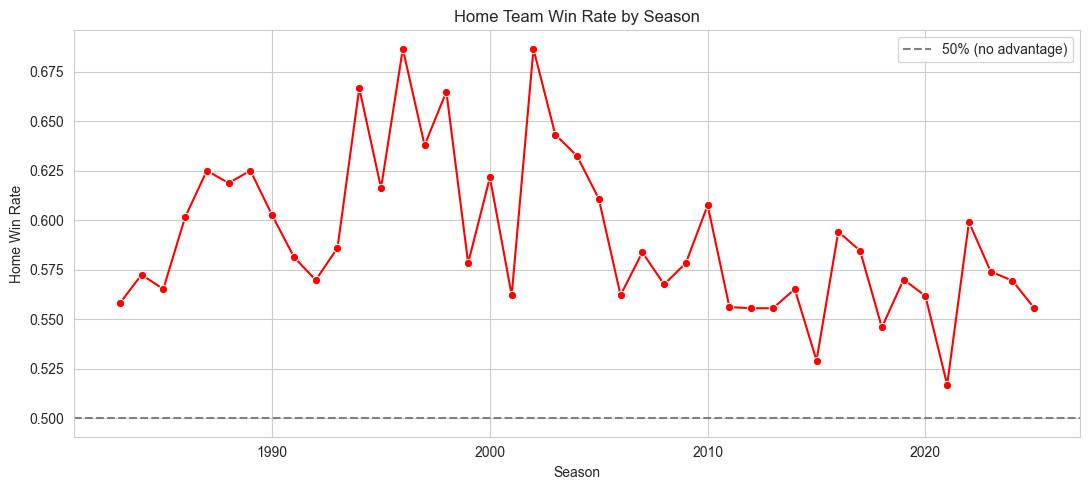

Overall home win rate across all seasons: 59.1%


In [23]:
home_win_rate_by_year = matches.groupby('year')['home_win'].mean()

fig, ax = plt.subplots(figsize=(11,5))
sns.lineplot(x=home_win_rate_by_year.index, y=home_win_rate_by_year.values, marker='o', ax=ax, color="red")
ax.axhline(0.5, color='gray', linestyle='--', label='50% (no advantage)')
ax.set_title('Home Team Win Rate by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Home Win Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Overall home win rate across all seasons: {matches['home_win'].mean():.1%}")

Home teams win more often than not in almost every season, sitting well above the 50% line most years. That's the home ground advantage effect and it's worth being a real feature (not just noise) for the win predictor.

#### 2. Margin distribution: home vs away wins

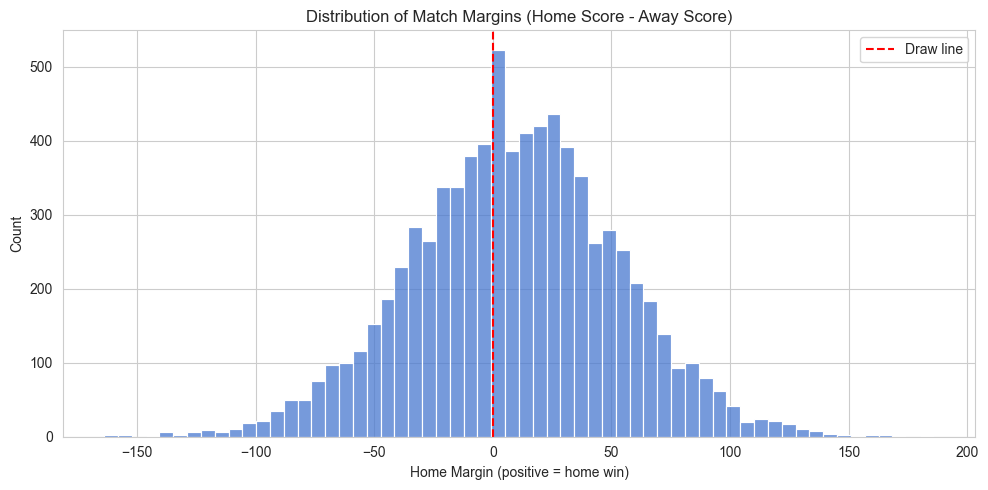

count    7904.000000
mean        8.966473
std        43.865851
min      -164.000000
25%       -20.000000
50%         9.000000
75%        38.000000
max       186.000000
Name: home_margin, dtype: float64


In [24]:
matches['home_margin'] = matches['home_score'] - matches['away_score']

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(data=matches, x='home_margin', bins=60, ax=ax)
ax.axvline(0, color='red', linestyle='--', label='Draw line')
ax.set_title('Distribution of Match Margins (Home Score - Away Score)')
ax.set_xlabel('Home Margin (positive = home win)')
plt.legend()
plt.tight_layout()
plt.show()

print(matches['home_margin'].describe())

The margin distribution is centered slightly on the positive side (home teams), roughly bell-shaped, and pretty wide, matches can swing by well over 100 points.

#### 3. Top disposal-getters and goal-kickers, all time (season-level, from merged_players)

C:\Users\imama\AppData\Local\Temp\ipykernel_2024\2309845192.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_disposals, y='player_name', x='total_disposals', ax=axes[0], palette = "magma")
C:\Users\imama\AppData\Local\Temp\ipykernel_2024\2309845192.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_goals, y='player_name', x='total_goals', ax=axes[1], palette = "rocket_r")


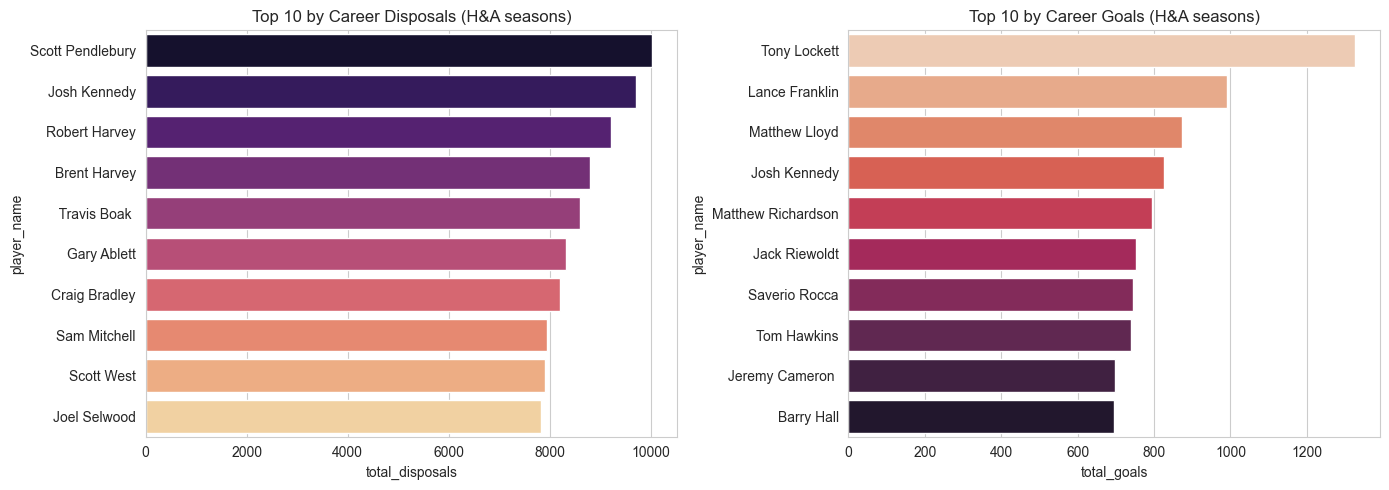

In [25]:
season_totals = merged[merged['is_finals'] == False].groupby('player_name').agg(
    total_disposals=('disposals','sum'),
    total_goals=('goals','sum'),
    seasons_played=('year','nunique')
).reset_index()

top_disposals = season_totals.sort_values('total_disposals', ascending=False).head(10)
top_goals = season_totals.sort_values('total_goals', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=top_disposals, y='player_name', x='total_disposals', ax=axes[0], palette = "magma")
axes[0].set_title('Top 10 by Career Disposals (H&A seasons)')
sns.barplot(data=top_goals, y='player_name', x='total_goals', ax=axes[1], palette = "rocket_r")
axes[1].set_title('Top 10 by Career Goals (H&A seasons)')
plt.tight_layout()
plt.show()

#### 4. Week-to-week consistency of top players

How stable is a player's output from game to game? Comparing the average fantasy points to the standard deviation, for players with a solid sample size, shows who's consistently good vs boom-or-bust.

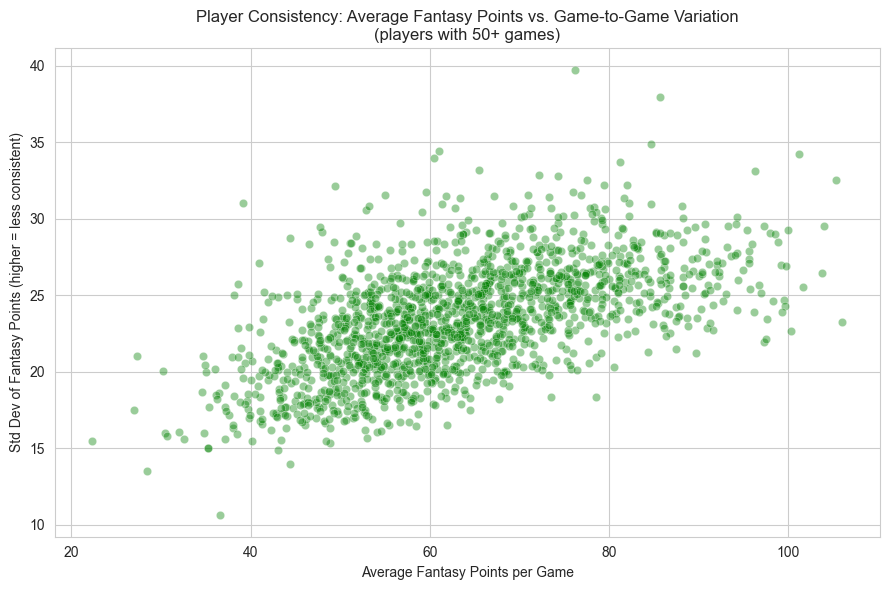

Correlation between average output and variability: 0.58


In [26]:
player_consistency = players.groupby('player_id').agg(
    games=('fantasy_points','count'),
    avg_fantasy=('fantasy_points','mean'),
    std_fantasy=('fantasy_points','std')
).reset_index()

# only players with a real sample size
player_consistency = player_consistency[player_consistency['games'] >= 50]

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=player_consistency, x='avg_fantasy', y='std_fantasy', alpha=0.4, ax=ax, color = "green")
ax.set_title('Player Consistency: Average Fantasy Points vs. Game-to-Game Variation\n(players with 50+ games)')
ax.set_xlabel('Average Fantasy Points per Game')
ax.set_ylabel('Std Dev of Fantasy Points (higher = less consistent)')
plt.tight_layout()
plt.show()

print(f"Correlation between average output and variability: {player_consistency['avg_fantasy'].corr(player_consistency['std_fantasy']):.2f}")

There's a positive relationship, players who score higher on average also tend to have bigger game-to-game swings (higher variance), which makes sense: a player who's a genuine star has more "big game" ceiling but also off nights, while a low-average player has a tighter, lower band.

**Note on position:** the task asks for forward vs midfielder vs defender comparisons, but none of the three files include a `position` field for players. This isn't something that can be built from the data given, it's flagged here as a real gap rather than guessed at (e.g. inferring position from stat profile would be a modeling assumption, not a fact from the data).

#### 5. Recent form vs. win probability

Does a team's win rate over its last 5 matches predict whether it wins the next one? This uses a leakage-safe rolling average (only past matches, shifted so the current match isn't included in its own "recent form").

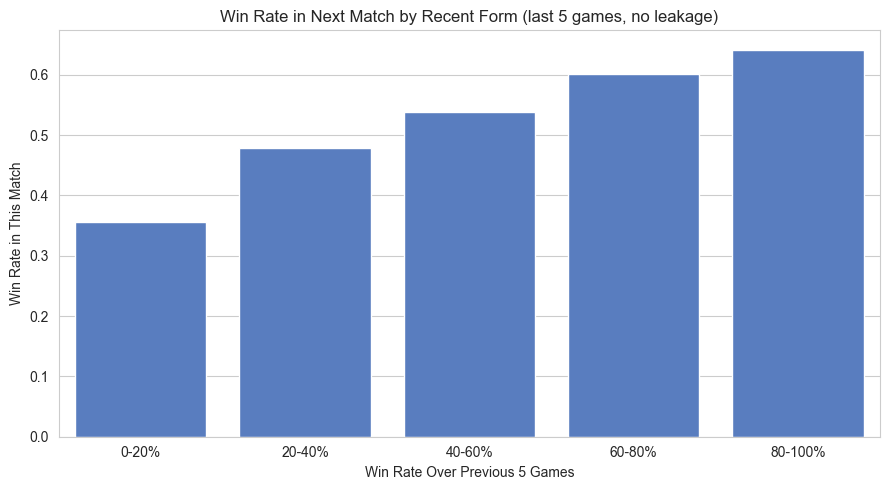

In [27]:
# build long form: one row per team per match, using the cleaned team_matches table
team_long = team_matches.copy()
team_long['match_date'] = pd.to_datetime(team_long['match_date'])
team_long['team_win'] = (team_long['result'] == 'W').astype(int)
team_long = team_long.sort_values(['team_name','match_date'])

# rolling win rate over the last 5 matches, shifted so it excludes the current match
team_long['recent_form_5'] = (
    team_long.groupby('team_name')['team_win']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())
)

form_vs_outcome = team_long.dropna(subset=['recent_form_5']).copy()
form_vs_outcome['form_bucket'] = pd.cut(form_vs_outcome['recent_form_5'], 
                                         bins=[-0.01,0.2,0.4,0.6,0.8,1.01],
                                         labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])

form_summary = form_vs_outcome.groupby('form_bucket', observed=True)['team_win'].mean()

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=form_summary.index, y=form_summary.values, ax=ax)
ax.set_title('Win Rate in Next Match by Recent Form (last 5 games, no leakage)')
ax.set_xlabel('Win Rate Over Previous 5 Games')
ax.set_ylabel('Win Rate in This Match')
plt.tight_layout()
plt.show()

Teams that have been winning recently are clearly more likely to win their next match too, the bars step up pretty cleanly left to right. This confirms "recent form" is worth building as a real feature (done properly in Task 4, with the same shift-before-rolling logic used here so there's no leakage from the match being predicted).

## Task 4: Feature Engineering for Prediction

All rolling features below are built the same way: **sort by date, then shift by 1 before taking the rolling window.** That guarantees the feature for a given match only uses information from matches strictly before it, never the match itself or anything after it.

Everything is built at the team-match level (`team_long`, one row per team per match) since that's what both the winner model and the "recent form" pieces of the chat agent will need.

In [28]:
feat = team_long.copy()

# Rolling/form features 
# last 5-game win rate (already built above, keep it)
# last 5-game average score
feat['avg_score_last5'] = (
    feat.groupby('team_name')['team_score']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())
)

# current win/loss streak going into this match (positive = win streak, negative = loss streak)
def win_streak(results):
    streak = []
    current = 0
    last_result = None
    for r in results:
        if last_result is None:
            streak.append(0)
        else:
            if last_result == 'W':
                current = current + 1 if current >= 0 else 1
            elif last_result == 'L':
                current = current - 1 if current <= 0 else -1
            else:
                current = 0
            streak.append(current)
        last_result = r
    return streak

feat = feat.sort_values(['team_name','match_date'])
feat['win_streak_entering_match'] = feat.groupby('team_name')['result'].transform(
    lambda s: pd.Series(win_streak(s.tolist()), index=s.index)
)

print("Rolling/form features")
feat[['team_name','match_date','result','recent_form_5','avg_score_last5','win_streak_entering_match']].tail(8)

Rolling/form features


,team_name,match_date,result,recent_form_5,avg_score_last5,win_streak_entering_match
553,Western Bulldogs,2025-07-03,W,0.6,108.8,3
1408,Western Bulldogs,2025-07-12,L,0.8,113.0,4
554,Western Bulldogs,2025-07-18,L,0.8,120.8,-1
1420,Western Bulldogs,2025-07-25,W,0.6,109.6,-2
555,Western Bulldogs,2025-07-31,W,0.6,111.2,1
556,Western Bulldogs,2025-08-10,W,0.6,116.6,2
557,Western Bulldogs,2025-08-17,W,0.6,110.8,3
558,Western Bulldogs,2025-08-24,L,0.8,116.4,4


#### New Rolling Feature Descrption:
* **recent_form_5** : What percentage of the team's last 5 games did they win? (e.g., 0.8 = won 4 out of the last 5)
* **avg_score_last5** : On average, how many points did the team score in its last 5 games?
* **win_streak_entering_match** : How many wins or losses in a row did the team have before this match?

Positive values mean a winning streak, negative values mean a losing streak, and 0 means no streak or it's the team's first game.

### Rest days


In [29]:
feat['days_rest'] = feat.groupby('team_name')['match_date'].diff().dt.days

In [30]:
feat[['team_name', 'days_rest']].head()

,team_name,days_rest
3340,Adelaide Crows,NaN
13583,Adelaide Crows,9.0
13585,Adelaide Crows,7.0
13586,Adelaide Crows,6.0
13587,Adelaide Crows,8.0


### Ladder position at time of match:
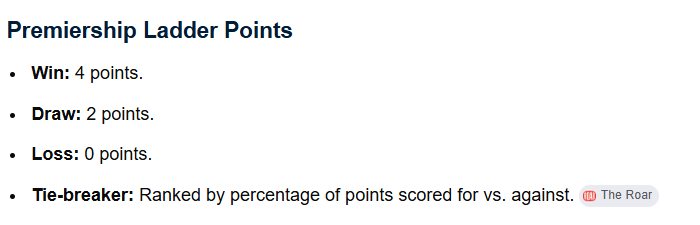


In [31]:

# cumulative points within a season, before this match (4 for a win, 2 for a draw, 0 for a loss - standard AFL points)
feat['match_points'] = feat['result'].map({'W': 4, 'D': 2, 'L': 0})
feat['points_before_match'] = (
    feat.groupby(['team_name','year'])['match_points']
    .transform(lambda s: s.shift(1).cumsum().fillna(0))
)

# ladder position before this match = rank within that round, by points_before_match, per season
feat['ladder_position_before_match'] = (
    feat.groupby(['year','round'])['points_before_match']
    .rank(method='min', ascending=False)
)

feat[['team_name','year','round','points_before_match','ladder_position_before_match']].tail(6)

,team_name,year,round,points_before_match,ladder_position_before_match
554,Western Bulldogs,2025,19,40.0,9.0
1420,Western Bulldogs,2025,20,40.0,9.0
555,Western Bulldogs,2025,21,44.0,9.0
556,Western Bulldogs,2025,22,48.0,9.0
557,Western Bulldogs,2025,23,52.0,9.0
558,Western Bulldogs,2025,24,56.0,8.0


### Head-to-head record

In [32]:
# win rate against this specific opponent, from matches strictly before this one
feat = feat.sort_values(['team_name','opponent','match_date'])
feat['h2h_win_rate_vs_opponent'] = (
    feat.groupby(['team_name','opponent'])['team_win']
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
)
feat = feat.sort_values(['team_name','match_date'])

feat[['team_name','opponent','match_date','team_win','h2h_win_rate_vs_opponent']].head(10)

,team_name,opponent,match_date,team_win,h2h_win_rate_vs_opponent
3340,Adelaide Crows,hawthorn hawks,1991-03-22,1,NaN
13583,Adelaide Crows,Carlton Blues,1991-03-31,0,NaN
13585,Adelaide Crows,Sydney Swans,1991-04-07,1,NaN
13586,Adelaide Crows,Essendon Bombers,1991-04-13,0,NaN
13587,Adelaide Crows,West Coast Eagles,1991-04-21,0,NaN
13588,Adelaide Crows,Western Bulldogs,1991-04-28,1,NaN
13589,Adelaide Crows,St Kilda Saints,1991-05-04,0,NaN
13594,Adelaide Crows,North Melbourne Kangaroos,1991-05-17,0,NaN
15785,Adelaide Crows,melbourne demons,1991-05-24,1,NaN
13595,Adelaide Crows,Geelong Cats,1991-06-01,0,NaN


### Venue feature

In [33]:
# team's historical win rate at this specific venue, strictly before this match
feat = feat.sort_values(['team_name','venue','match_date'])
feat['venue_win_rate'] = (
    feat.groupby(['team_name','venue'])['team_win']
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
)
feat = feat.sort_values(['team_name','match_date']).reset_index(drop=True)

print("All team-match features built. Shape:", feat.shape)

All team-match features built. Shape: (15808, 29)


In [34]:
feat['venue_win_rate']

0             NaN
1        1.000000
2             NaN
3             NaN
4             NaN
           ...   
15803    0.524752
15804    0.526316
15805    0.452055
15806    0.527869
15807    0.529412
Name: venue_win_rate, Length: 15808, dtype: float64

In [35]:
feat

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds,team_win,recent_form_5,avg_score_last5,win_streak_entering_match,days_rest,match_points,points_before_match,ladder_position_before_match,h2h_win_rate_vs_opponent,venue_win_rate
0,10223,Adelaide Crows,1,1991-03-22,1991,H,hawthorn hawks,6.2 11.6 17.10 24.11,155,2.0 3.3 6.8 9.15,69,W,86,AAMI Stadium,44902.0,24,11,9,15,1,NaN,NaN,0,NaN,4,0.0,1.0,NaN,NaN
1,10224,Adelaide Crows,2,1991-03-31,1991,H,Carlton Blues,3.2 5.3 9.6 12.9,81,3.4 5.9 11.10 15.14,104,L,-23,AAMI Stadium,43850.0,12,9,15,14,0,NaN,NaN,1,9.0,0,4.0,1.0,NaN,1.000000
2,10225,Adelaide Crows,3,1991-04-07,1991,A,Sydney Swans,3.3 6.7 13.10 19.18,132,2.5 8.8 11.14 15.18,108,W,24,Sydney Cricket Ground,10649.0,19,18,15,18,1,NaN,NaN,-1,7.0,4,4.0,1.0,NaN,NaN
3,10226,Adelaide Crows,4,1991-04-13,1991,A,Essendon Bombers,2.1 4.7 6.9 6.11,47,5.4 8.9 9.15 12.20,92,L,-45,Windy Hill,20197.0,6,11,12,20,0,0.666667,122.666667,1,6.0,0,8.0,1.0,NaN,NaN
4,10227,Adelaide Crows,5,1991-04-21,1991,A,West Coast Eagles,0.3 2.8 5.9 9.11,65,5.4 9.7 15.10 19.16,130,L,-65,Domain Stadium,34704.0,9,11,19,16,0,0.500000,103.750000,-1,8.0,0,8.0,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15803,10210,Western Bulldogs,20,2025-07-25,2025,A,essendon bombers,6.5 10.5 17.7 22.11,143,2.2 2.5 4.6 7.8,50,W,93,Marvel Stadium,29367.0,22,11,7,8,1,0.600000,109.600000,-2,7.0,4,40.0,9.0,0.375000,0.524752
15804,10211,Western Bulldogs,21,2025-07-31,2025,H,Greater Western Sydney Giants,6.5 12.9 16.13 19.18,132,1.2 3.2 6.6 6.8,44,W,88,Marvel Stadium,23898.0,19,18,6,8,1,0.600000,111.200000,1,6.0,4,44.0,9.0,0.631579,0.526316
15805,10212,Western Bulldogs,22,2025-08-10,2025,A,Melbourne Demons,3.6 5.10 9.11 15.15,105,3.4 4.6 11.9 15.9,99,W,6,Melbourne Cricket Ground,34733.0,15,15,15,9,1,0.600000,116.600000,2,10.0,4,48.0,9.0,0.564516,0.452055
15806,10213,Western Bulldogs,23,2025-08-17,2025,H,West Coast Eagles,4.5 11.7 15.7 19.12,126,0.1 2.5 3.8 4.8,32,W,94,Marvel Stadium,21207.0,19,12,4,8,1,0.600000,110.800000,3,7.0,4,52.0,9.0,0.384615,0.527869


### Player-level rolling features

So the same leakage safe pattern is gonna get applied to `players` for the player-output side of prediction (top disposal-getter / top goal-kicker / composite)S

In [36]:
players_sorted = players.copy()
players_sorted['match_date'] = pd.to_datetime(players_sorted['match_date'])
players_sorted = players_sorted.sort_values(['player_id','match_date'])

players_sorted['avg_disposals_last5'] = (
    players_sorted.groupby('player_id')['disposals']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=2).mean())
)
players_sorted['avg_goals_last5'] = (
    players_sorted.groupby('player_id')['goals']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=2).mean())
)
players_sorted['avg_fantasy_last5'] = (
    players_sorted.groupby('player_id')['fantasy_points']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=2).mean())
)

players_sorted[['player_id','team','match_date','disposals','avg_disposals_last5',
                'goals','avg_goals_last5','fantasy_points','avg_fantasy_last5']].tail(6)

,player_id,team,match_date,disposals,avg_disposals_last5,goals,avg_goals_last5,fantasy_points,avg_fantasy_last5
259648,46373,Carlton Blues,2007-05-19,10.0,11.50,NaN,NaN,35,45.5
259646,46373,Carlton Blues,2007-06-30,12.0,11.00,2.0,NaN,62,42.0
259647,46373,Carlton Blues,2007-07-08,12.0,11.25,NaN,1.5,76,47.0
259650,46373,Carlton Blues,2007-07-15,11.0,11.40,NaN,1.5,52,52.8
259642,46374,Adelaide Crows,2010-04-04,10.0,NaN,NaN,NaN,36,NaN
273695,46374,Adelaide Crows,2010-08-21,2.0,NaN,1.0,NaN,27,NaN


### Saving the versioned feature table

Both feature tables (team-match level and player-match level) get saved together with a version tag, so Day 2's models point at one fixed file instead of re-deriving features each time

In [38]:
players_info = pd.read_csv("players_info.csv")
print(players_info.columns.tolist())

['id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'profile_pic', 'player_link', 'player_common_names', 'player_teams']


In [39]:
FEATURE_VERSION = "v1_2026-07-27"

team_feature_cols = ['team_name','opponent','match_date','year','round','venue','home_away',
                     'result','team_win','recent_form_5','avg_score_last5',
                     'win_streak_entering_match','days_rest','points_before_match',
                     'ladder_position_before_match','h2h_win_rate_vs_opponent','venue_win_rate']

player_feature_cols = ['player_id','team','opponent','match_date','year','round',
                       'disposals','goals','fantasy_points',
                       'avg_disposals_last5','avg_goals_last5','avg_fantasy_last5']

team_features_out = feat[team_feature_cols].copy()
player_features_out = players_sorted[player_feature_cols].copy()

# ----------------- ADD PLAYER NAMES -----------------
players_info = pd.read_csv("players_info.csv")

player_names = (
    players_info
    .rename(columns={"id": "player_id"})[
        ["player_id", "player_name"]
    ]
    .drop_duplicates(subset="player_id")
)

player_features_out = player_features_out.merge(
    player_names,
    on="player_id",
    how="left"
)
# ----------------------------------------------------

team_features_out.to_csv(f'team_match_features_{FEATURE_VERSION}.csv', index=False)
player_features_out.to_csv(f'player_match_features_{FEATURE_VERSION}.csv', index=False)

print("Saved:")
print(f" - team_match_features_{FEATURE_VERSION}.csv  ({team_features_out.shape[0]} rows)")
print(f" - player_match_features_{FEATURE_VERSION}.csv ({player_features_out.shape[0]} rows)")

Saved:
 - team_match_features_v1_2026-07-27.csv  (15808 rows)
 - player_match_features_v1_2026-07-27.csv (274089 rows)


In [40]:
feature_dictionary = pd.DataFrame([
    {"feature": "recent_form_5", "table": "team_match_features", "window": "last 5 games (shifted)",
     "description": "team's win rate over its previous 5 matches, not counting this one", "source_cols": "result"},
    {"feature": "avg_score_last5", "table": "team_match_features", "window": "last 5 games (shifted)",
     "description": "team's average score over its previous 5 matches", "source_cols": "team_score"},
    {"feature": "win_streak_entering_match", "table": "team_match_features", "window": "running, as of before this match",
     "description": "current win streak (positive) or loss streak (negative) entering this match", "source_cols": "result"},
    {"feature": "days_rest", "table": "team_match_features", "window": "since last match",
     "description": "days between this match and the team's previous match", "source_cols": "match_date"},
    {"feature": "points_before_match", "table": "team_match_features", "window": "season to date (shifted)",
     "description": "ladder points accumulated this season before this match (4=win,2=draw,0=loss)", "source_cols": "result"},
    {"feature": "ladder_position_before_match", "table": "team_match_features", "window": "as of this round",
     "description": "rank on the ladder (by points_before_match) among all teams, before this match", "source_cols": "points_before_match"},
    {"feature": "h2h_win_rate_vs_opponent", "table": "team_match_features", "window": "all prior meetings (shifted)",
     "description": "win rate against this specific opponent, from all matches before this one", "source_cols": "result, opponent"},
    {"feature": "venue_win_rate", "table": "team_match_features", "window": "all prior matches at venue (shifted)",
     "description": "team's historical win rate at this specific venue, before this match", "source_cols": "result, venue"},
    {"feature": "avg_disposals_last5", "table": "player_match_features", "window": "last 5 games (shifted)",
     "description": "player's average disposals over their previous 5 matches", "source_cols": "disposals"},
    {"feature": "avg_goals_last5", "table": "player_match_features", "window": "last 5 games (shifted)",
     "description": "player's average goals over their previous 5 matches", "source_cols": "goals"},
    {"feature": "avg_fantasy_last5", "table": "player_match_features", "window": "last 5 games (shifted)",
     "description": "player's average fantasy points over their previous 5 matches", "source_cols": "fantasy_points"},
])
feature_dictionary

,feature,table,window,description,source_cols
0,recent_form_5,team_match_features,last 5 games (shifted),"team's win rate over its previous 5 matches, n...",result
1,avg_score_last5,team_match_features,last 5 games (shifted),team's average score over its previous 5 matches,team_score
2,win_streak_entering_match,team_match_features,"running, as of before this match",current win streak (positive) or loss streak (...,result
3,days_rest,team_match_features,since last match,days between this match and the team's previou...,match_date
4,points_before_match,team_match_features,season to date (shifted),ladder points accumulated this season before t...,result
5,ladder_position_before_match,team_match_features,as of this round,rank on the ladder (by points_before_match) am...,points_before_match
6,h2h_win_rate_vs_opponent,team_match_features,all prior meetings (shifted),"win rate against this specific opponent, from ...","result, opponent"
7,venue_win_rate,team_match_features,all prior matches at venue (shifted),team's historical win rate at this specific ve...,"result, venue"
8,avg_disposals_last5,player_match_features,last 5 games (shifted),player's average disposals over their previous...,disposals
9,avg_goals_last5,player_match_features,last 5 games (shifted),player's average goals over their previous 5 m...,goals


## Task 5: Reproducible Train/Hold-Out Split

### Why a random split would leak information

A random split (e.g. `train_test_split` with `shuffle=True`) would put some matches from 2024 in the training set and some matches from 2010 in the test set. Since the rolling/form features for any match depend on that team's *entire prior history*, a randomly split test match from an early season could end up with training data from matches that happened years later, or worse, a test match's "future" opponents/venues could already be baked into other rows the model trained on. In a real sports prediction context, you always know the past and never know the future, so the evaluation setup needs to reflect that: **train strictly on earlier time, test strictly on later time.**

### The split function

In [41]:
def time_based_split(df, date_col='match_date', holdout_last_n_seasons=1, year_col='year'):
    """
    Splits a dataframe into train/holdout by season, not randomly.
    Holds out the most recent N seasons as the test set, trains on everything before that.
    Every model this week should call this function so all models see the exact same split.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    max_year = df[year_col].max()
    cutoff_year = max_year - holdout_last_n_seasons + 1

    train = df[df[year_col] < cutoff_year].copy()
    holdout = df[df[year_col] >= cutoff_year].copy()
    return train, holdout

train_matches, holdout_matches = time_based_split(feat, holdout_last_n_seasons=1)

print(f"Train: {train_matches['year'].min()}-{train_matches['year'].max()}, {len(train_matches)} rows")
print(f"Holdout: {holdout_matches['year'].min()}-{holdout_matches['year'].max()}, {len(holdout_matches)} rows")

Train: 1983-2024, 15376 rows
Holdout: 2025-2025, 432 rows


### Realistic accuracy ceiling

Sports outcomes are inherently unpredictable because factors such as injuries, player form, weather, and unexpected events can all influence the result of a match. A realistic prediction accuracy for AFL match winners would likely be around **65–75%**, with higher values becoming increasingly difficult to achieve consistently.

Achieving 95+% accuracy would be highly unlikely and would suggest that the model has access to information it should not have, such as future match results or post-match statistics. This type of issue is known as data leakage, where information from the future unintentionally influences the model during training or evaluation



## Summary

- Loaded and documented all three files: what each row means, the date range (1983-2025), team/player counts, and how they join.
- Fixed a real team-naming inconsistency in `team_matches` (whitespace/tabs + `W. Bulldogs` abbreviation) and flagged (without altering) 723 rows with impossible negative disposals.
- Locked in target definitions: `match_winner` as a 3-class classification target, plus two `top_player` definitions (disposals, goals) and a fantasy-points composite, all documented in a data dictionary.
- Ran 5 EDA visualizations covering home ground advantage, margin spread, all-time leaders, player consistency, and recent form vs win probability.
- Built leakage-safe rolling features (form, streaks, rest days, ladder position, head-to-head, venue) at both team-match and player-match level, and saved them as a versioned CSV pair for Day 2.
- Built and documented a reusable time-based train/holdout split function, and set expectations for what "good" accuracy actually looks like in this domain.